# 財經新聞情緒分析 × 股價預測

用三種方法(詞典法、現成財經 BERT、自己 fine-tune 的 BERT)為台積電(2330)新聞標題做情緒分類，
比較準確率，再檢驗情緒分數與股價報酬率的關係，最後看情緒特徵能否幫助預測次日漲跌方向。

完整方法論與結論見 [README.md](../README.md)。這份 notebook 只是把 `src/` 裡的函式串起來重現分析，
不重複寫核心邏輯。

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.sentiment_models import (
    dict_sentiment, load_pretrained_bert, bert_sentiment,
    load_finetuned_bert, predict_sentiment,
)
from src.feature_engineering import (
    build_daily_sentiment, merge_price_sentiment, add_features,
    time_based_split, FEATURES_NO_SENTIMENT, FEATURES_WITH_SENTIMENT,
)
from src.prediction_models import (
    run_baselines, full_report, cross_validate, paired_ttest,
    logistic_regression_factory, random_forest_factory, feature_importance,
)
from src.data_collection import fetch_price_data
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import pearsonr

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("../data")

C:\Users\hw453\Desktop\side\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 資料載入

新聞標題來自 FinMind(`taiwan_stock_news`)，股價來自 yfinance。抓取程式碼見 `src/data_collection.py`；
這裡直接讀取已抓好的 `data/news_2330.csv`。

In [2]:
news_df = pd.read_csv(DATA_DIR / "news_2330.csv")
news_df = news_df.drop_duplicates(subset=["title"]).reset_index(drop=True)
print(f"新聞標題數(去重後): {len(news_df)}")
print(f"日期範圍: {news_df['date'].min()} ~ {news_df['date'].max()}")
news_df.head()

新聞標題數(去重後): 14594
日期範圍: 2024-01-01 03:00:00 ~ 2025-09-01 23:15:51


,date,stock_id,link,source,title
0,2024-01-01 03:00:00,2330,https://news.google.com/rss/articles/CBMiLmh0d...,經濟日報,晶圓雙雄再成焦點 台積電平穩向上、聯電爆量上揚 該買哪一檔？ - 經濟日報
1,2024-01-01 08:00:00,2330,https://news.google.com/rss/articles/CBMipgJod...,Yahoo奇摩股市,【台積電股東爆下車潮2】600元是散戶心中天花板價？專家這麼看 - Yahoo奇摩股市
2,2024-01-01 08:00:00,2330,https://news.google.com/rss/articles/CBMiqAJod...,Yahoo奇摩股市,【台積電股東爆下車潮1】台積電股價創21月新高31萬股東卻下車了 - Yahoo奇摩股市
3,2024-01-01 08:00:00,2330,https://news.google.com/rss/articles/CBMi5AFod...,Yahoo奇摩新聞,台積電今年重返成長軌道 營收挑戰2.5兆元…年增逾15% - Yahoo奇摩新聞
4,2024-01-01 08:00:00,2330,https://news.google.com/rss/articles/CBMi5AFod...,Yahoo奇摩新聞,台積電今年重返成長軌道營收挑戰2.5兆元…年增逾15% - Yahoo奇摩新聞


## 2. 情緒分類方法比較

用 150 則人工標註的新聞(`data/to_label.csv`)當測試集，比較三種方法：

1. **詞典法**：關鍵字命中判斷正負面
2. **現成財經 BERT**：`sanshizhang/Chinese-Sentiment-Analysis-Fund-Direction`
3. **Fine-tuned BERT**：`hfl/chinese-macbert-base` 在 ChnSentiCorp 上微調(訓練程式碼見 `src/train_bert.py`，實際在 Colab 用 GPU 跑)


In [3]:
sample = pd.read_csv(DATA_DIR / "to_label.csv")
print(f"人工標註測試集: {len(sample)} 則")
sample["label"].value_counts()

人工標註測試集: 150 則


label
 1    97
-1    28
 0    25
Name: count, dtype: int64

In [4]:
# 方法一：詞典法
sample["sentiment_dict"] = sample["title"].apply(dict_sentiment)
print("詞典法 vs 人工標註:")
print(classification_report(sample["label"], sample["sentiment_dict"]))
acc_dict = accuracy_score(sample["label"], sample["sentiment_dict"])

詞典法 vs 人工標註:
              precision    recall  f1-score   support

          -1       1.00      0.25      0.40        28
           0       0.18      0.96      0.31        25
           1       0.69      0.09      0.16        97

    accuracy                           0.27       150
   macro avg       0.63      0.43      0.29       150
weighted avg       0.67      0.27      0.23       150



In [5]:
# 方法二：現成財經 BERT
pretrained_tokenizer, pretrained_model = load_pretrained_bert()
sample["sentiment_bert"] = sample["title"].apply(
    lambda t: bert_sentiment(t, pretrained_tokenizer, pretrained_model)[0]
)
print("現成財經 BERT vs 人工標註:")
print(classification_report(sample["label"], sample["sentiment_bert"]))
acc_pretrained = accuracy_score(sample["label"], sample["sentiment_bert"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 39295.94it/s]

現成財經 BERT vs 人工標註:
              precision    recall  f1-score   support

          -1       0.25      0.25      0.25        28
           0       0.08      0.04      0.05        25
           1       0.67      0.76      0.71        97

    accuracy                           0.55       150
   macro avg       0.34      0.35      0.34       150
weighted avg       0.50      0.55      0.52       150



In [6]:
# 方法三：自己 fine-tune 的 BERT
finetuned_tokenizer, finetuned_model = load_finetuned_bert("../models/my_finetuned_bert")
sample["sentiment_finetuned"] = sample["title"].apply(
    lambda t: predict_sentiment(t, finetuned_tokenizer, finetuned_model)
)
print("Fine-tuned BERT vs 人工標註:")
print(classification_report(sample["label"], sample["sentiment_finetuned"]))
acc_finetuned = accuracy_score(sample["label"], sample["sentiment_finetuned"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:  11%|█         | 22/201 [00:00<00:00, 217.95it/s]

Loading weights:  22%|██▏       | 45/201 [00:00<00:00, 222.05it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 965.60it/s]

Fine-tuned BERT vs 人工標註:
              precision    recall  f1-score   support

          -1       0.45      0.93      0.60        28
           0       0.40      0.08      0.13        25
           1       0.84      0.75      0.79        97

    accuracy                           0.67       150
   macro avg       0.56      0.59      0.51       150
weighted avg       0.69      0.67      0.65       150



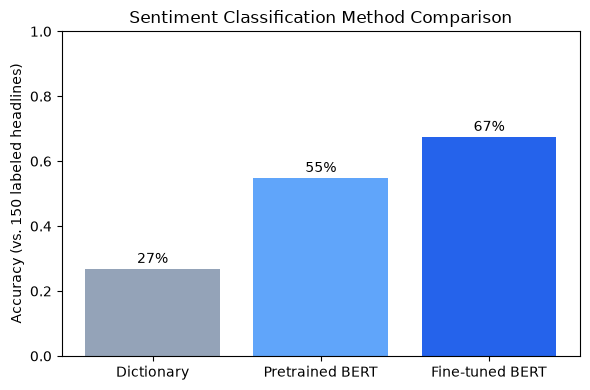

,method,method_en,accuracy
0,詞典法,Dictionary,0.266667
1,現成財經 BERT,Pretrained BERT,0.546667
2,Fine-tuned BERT,Fine-tuned BERT,0.673333


In [7]:
comparison = pd.DataFrame({
    "method": ["詞典法", "現成財經 BERT", "Fine-tuned BERT"],
    "method_en": ["Dictionary", "Pretrained BERT", "Fine-tuned BERT"],
    "accuracy": [acc_dict, acc_pretrained, acc_finetuned],
})
comparison.to_csv(RESULTS_DIR / "sentiment_method_comparison.csv", index=False)

# matplotlib's default font has no CJK glyphs, so charts use English labels
# (method_en) even though the underlying data/tables stay in Chinese.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(comparison["method_en"], comparison["accuracy"], color=["#94a3b8", "#60a5fa", "#2563eb"])
ax.set_ylabel("Accuracy (vs. 150 labeled headlines)")
ax.set_ylim(0, 1)
ax.set_title("Sentiment Classification Method Comparison")
for bar, acc in zip(bars, comparison["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.0%}", ha="center")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sentiment_accuracy_comparison.png", dpi=150)
plt.show()
comparison

## 3. 對全部新聞套用情緒分類，計算每日情緒分數

用準確率最高的 fine-tuned BERT 為全部新聞標題打分，再依日期聚合成每日平均情緒分數。

> 對 14000+ 則標題跑 BERT 推論很花時間，這裡優先讀取快取結果(`data/news_2330_scored.csv`)；
> 若快取不存在則即時計算(可能需要十幾分鐘)。

In [8]:
scored_path = DATA_DIR / "news_2330_scored.csv"
if scored_path.exists():
    news_df = pd.read_csv(scored_path)
else:
    news_df["sentiment"] = news_df["title"].apply(
        lambda t: predict_sentiment(t, finetuned_tokenizer, finetuned_model)
    )
    news_df.to_csv(scored_path, index=False)

news_df["sentiment"].value_counts()

sentiment
 1    7147
-1    6969
 0     478
Name: count, dtype: int64

In [9]:
daily_sentiment = build_daily_sentiment(news_df)
daily_sentiment.head()

,date,avg_sentiment,news_count,positive_ratio
0,2024-01-01,0.200000,10,0.600000
1,2024-01-02,-0.190476,21,0.380952
2,2024-01-03,-0.565217,23,0.217391
3,2024-01-04,0.000000,8,0.500000
4,2024-01-05,-0.166667,12,0.333333


## 4. 情緒分數 vs. 股價報酬率相關性分析

合併每日情緒與台積電股價，檢驗「當日情緒 vs 當日報酬率」以及「當日情緒 vs 次日報酬率(領先一日)」的相關性。

In [10]:
price_df = fetch_price_data("2330.TW", start="2024-01-01", end="2025-09-01")
merged = merge_price_sentiment(daily_sentiment, price_df)
print(f"合併後共 {len(merged)} 天資料")
merged.head()

[*********************100%***********************]  1 of 1 completed

合併後共 389 天資料


,date,avg_sentiment,news_count,positive_ratio,Close,return
1,2024-01-03,-0.565217,23,0.217391,555.932922,-0.025295
2,2024-01-04,0.000000,8,0.500000,557.856506,0.003460
3,2024-01-05,-0.166667,12,0.333333,554.009155,-0.006897
4,2024-01-08,0.687500,16,0.812500,560.742065,0.012153
5,2024-01-09,0.500000,4,0.750000,563.627502,0.005146


In [11]:
corr_same_day, p_same_day = pearsonr(merged["avg_sentiment"], merged["return"])
print(f"當日情緒 vs 當日報酬率: r={corr_same_day:.4f}, p={p_same_day:.4f}")

merged_lead = merged.copy()
merged_lead["next_day_return"] = merged_lead["return"].shift(-1)
merged_lead = merged_lead.dropna()
corr_lead, p_lead = pearsonr(merged_lead["avg_sentiment"], merged_lead["next_day_return"])
print(f"當日情緒 vs 次日報酬率(領先一日): r={corr_lead:.4f}, p={p_lead:.4f}")

當日情緒 vs 當日報酬率: r=0.5736, p=0.0000
當日情緒 vs 次日報酬率(領先一日): r=-0.0232, p=0.6481


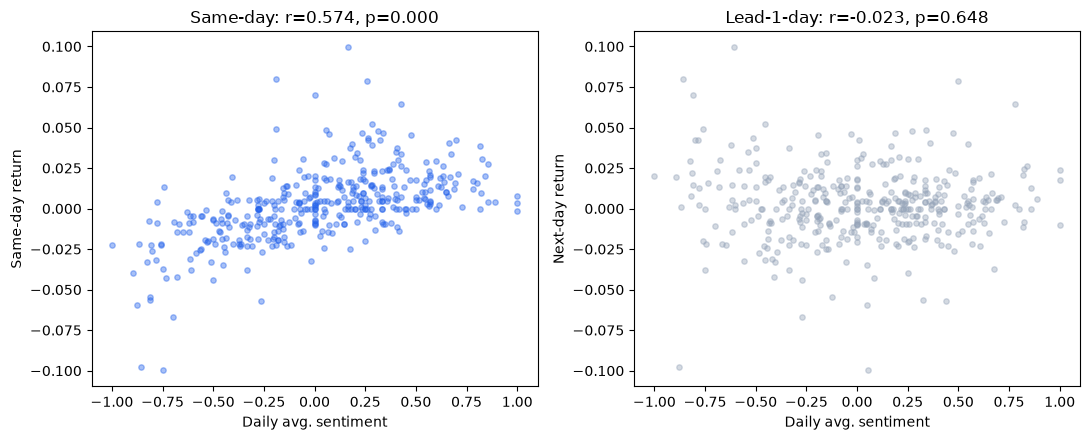

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(merged["avg_sentiment"], merged["return"], alpha=0.4, s=15, color="#2563eb")
axes[0].set_xlabel("Daily avg. sentiment")
axes[0].set_ylabel("Same-day return")
axes[0].set_title(f"Same-day: r={corr_same_day:.3f}, p={p_same_day:.3f}")

axes[1].scatter(merged_lead["avg_sentiment"], merged_lead["next_day_return"], alpha=0.4, s=15, color="#94a3b8")
axes[1].set_xlabel("Daily avg. sentiment")
axes[1].set_ylabel("Next-day return")
axes[1].set_title(f"Lead-1-day: r={corr_lead:.3f}, p={p_lead:.3f}")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sentiment_return_correlation.png", dpi=150)
plt.show()

**觀察**：當日情緒與當日報酬率高度相關，但領先一日後相關性幾乎消失且不顯著 —— 顯示情緒分數比較像是「同步反映」股價當天的漲跌(新聞在描述已發生的價格變化，例如「大漲」、「重挫」等字眼)，而非能提前預測隔天走勢的領先指標。

## 5. 特徵工程與次日漲跌方向預測

用過去的價格特徵(不偷看未來)加上情緒特徵，預測次日漲跌方向，比較「有無情緒特徵」的準確率差異。

In [13]:
df = add_features(merged)
print(f"最終資料筆數: {len(df)}")
df["target"].value_counts()

最終資料筆數: 384


target
1    198
0    186
Name: count, dtype: int64

In [14]:
train_df, test_df = time_based_split(df, train_ratio=0.8)
print(f"訓練集: {train_df['date'].min()} ~ {train_df['date'].max()}, {len(train_df)} 筆")
print(f"測試集: {test_df['date'].min()} ~ {test_df['date'].max()}, {len(test_df)} 筆")

訓練集: 2024-01-10 ~ 2025-05-12, 307 筆
測試集: 2025-05-13 ~ 2025-08-29, 77 筆


In [15]:
X_train_A, X_test_A = train_df[FEATURES_NO_SENTIMENT], test_df[FEATURES_NO_SENTIMENT]
X_train_B, X_test_B = train_df[FEATURES_WITH_SENTIMENT], test_df[FEATURES_WITH_SENTIMENT]
y_train, y_test = train_df["target"], test_df["target"]

baselines = run_baselines(train_df, test_df, y_test)

model_A = logistic_regression_factory().fit(X_train_A, y_train)
model_B = logistic_regression_factory().fit(X_train_B, y_train)
pred_A, pred_B = model_A.predict(X_test_A), model_B.predict(X_test_B)

full_report(y_test, baselines["majority_pred"], "Baseline(多數類別)")
full_report(y_test, baselines["momentum_pred"], "Baseline(動量)")
full_report(y_test, pred_A, "Logistic Regression(無情緒)")
full_report(y_test, pred_B, "Logistic Regression(有情緒)")


=== Baseline(多數類別) ===
Accuracy: 0.4935
Precision: 0.4935
Recall: 1.0000
F1: 0.6609

=== Baseline(動量) ===
Accuracy: 0.5584
Precision: 0.5500
Recall: 0.5789
F1: 0.5641

=== Logistic Regression(無情緒) ===
Accuracy: 0.5065
Precision: 0.5000
Recall: 0.0263
F1: 0.0500

=== Logistic Regression(有情緒) ===
Accuracy: 0.4675
Precision: 0.3636
Recall: 0.1053
F1: 0.1633


{'name': 'Logistic Regression(有情緒)',
 'accuracy': 0.4675324675324675,
 'precision': 0.36363636363636365,
 'recall': 0.10526315789473684,
 'f1': 0.16326530612244897}

### 5.1 Time-series cross-validation + 配對 t 檢定

In [16]:
scores_A_lr, scores_B_lr = cross_validate(
    df, FEATURES_NO_SENTIMENT, FEATURES_WITH_SENTIMENT, "target", logistic_regression_factory
)
print(f"LR 無情緒 各折: {[f'{s:.3f}' for s in scores_A_lr]}, 平均: {np.mean(scores_A_lr):.4f}")
print(f"LR 有情緒 各折: {[f'{s:.3f}' for s in scores_B_lr]}, 平均: {np.mean(scores_B_lr):.4f}")

t_lr, p_lr = paired_ttest(scores_B_lr, scores_A_lr)
print(f"配對 t 檢定(LR): t={t_lr:.4f}, p={p_lr:.4f}")

LR 無情緒 各折: ['0.562', '0.625', '0.531', '0.516', '0.484'], 平均: 0.5437
LR 有情緒 各折: ['0.594', '0.578', '0.531', '0.531', '0.500'], 平均: 0.5469
配對 t 檢定(LR): t=0.2325, p=0.8276


In [17]:
scores_A_rf, scores_B_rf = cross_validate(
    df, FEATURES_NO_SENTIMENT, FEATURES_WITH_SENTIMENT, "target", random_forest_factory
)
print(f"RF 無情緒 各折: {[f'{s:.3f}' for s in scores_A_rf]}, 平均: {np.mean(scores_A_rf):.4f}")
print(f"RF 有情緒 各折: {[f'{s:.3f}' for s in scores_B_rf]}, 平均: {np.mean(scores_B_rf):.4f}")

t_rf, p_rf = paired_ttest(scores_B_rf, scores_A_rf)
print(f"配對 t 檢定(RF): t={t_rf:.4f}, p={p_rf:.4f}")

RF 無情緒 各折: ['0.469', '0.578', '0.547', '0.469', '0.469'], 平均: 0.5062
RF 有情緒 各折: ['0.406', '0.641', '0.516', '0.484', '0.438'], 平均: 0.4969
配對 t 檢定(RF): t=-0.4286, p=0.6903


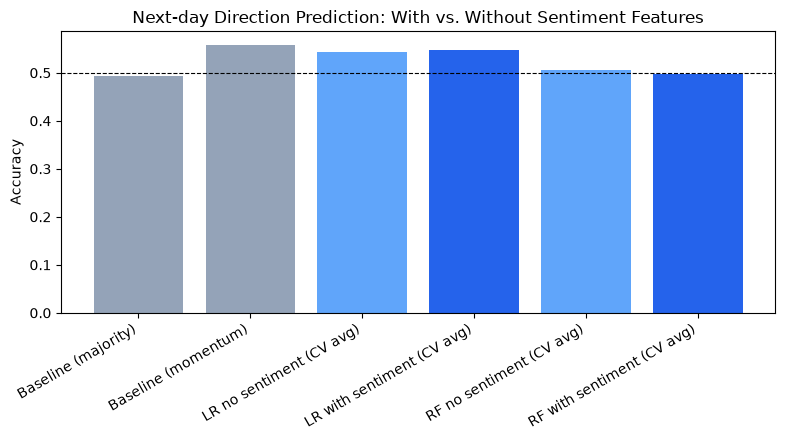

In [18]:
model_comparison = pd.DataFrame({
    "model": ["Baseline(多數類別)", "Baseline(動量)",
              "LR 無情緒(CV avg)", "LR 有情緒(CV avg)",
              "RF 無情緒(CV avg)", "RF 有情緒(CV avg)"],
    "model_en": ["Baseline (majority)", "Baseline (momentum)",
                 "LR no sentiment (CV avg)", "LR with sentiment (CV avg)",
                 "RF no sentiment (CV avg)", "RF with sentiment (CV avg)"],
    "accuracy": [baselines["Baseline(多數類別)"], baselines["Baseline(動量)"],
                 np.mean(scores_A_lr), np.mean(scores_B_lr),
                 np.mean(scores_A_rf), np.mean(scores_B_rf)],
})
model_comparison.to_csv(RESULTS_DIR / "prediction_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#94a3b8", "#94a3b8", "#60a5fa", "#2563eb", "#60a5fa", "#2563eb"]
ax.bar(model_comparison["model_en"], model_comparison["accuracy"], color=colors)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Accuracy")
ax.set_title("Next-day Direction Prediction: With vs. Without Sentiment Features")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=150)
plt.show()

### 5.2 特徵重要性(Random Forest)

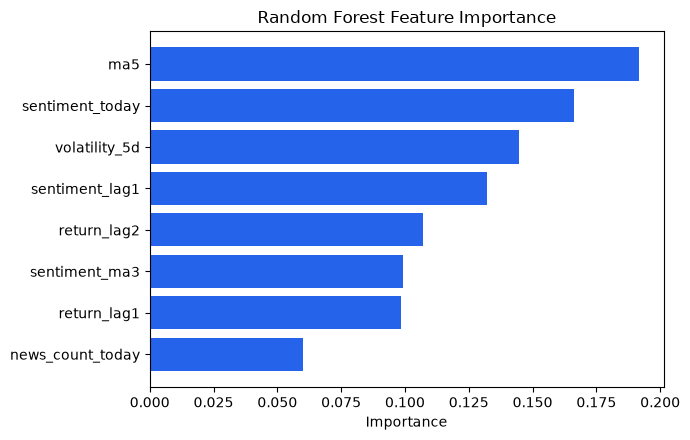

,feature,importance
2,ma5,0.191723
4,sentiment_today,0.166217
3,volatility_5d,0.144515
5,sentiment_lag1,0.132331
1,return_lag2,0.107067
7,sentiment_ma3,0.099322
0,return_lag1,0.098613
6,news_count_today,0.060213


In [19]:
rf_full = random_forest_factory().fit(df[FEATURES_WITH_SENTIMENT], df["target"])
importance_df = feature_importance(rf_full, FEATURES_WITH_SENTIMENT)
importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(importance_df["feature"], importance_df["importance"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_importance.png", dpi=150)
plt.show()
importance_df

## 6. 結論

- 三種情緒分類方法中，fine-tuned BERT 準確率最高(67%)，但即便如此，情緒特徵**沒有穩定地讓次日漲跌預測變準**：
  Logistic Regression、Random Forest 加入情緒特徵後的平均準確率變化都很小，配對 t 檢定都不顯著(p > 0.05)。
- 情緒分數與**當日**報酬率高度相關，但與**次日**報酬率的相關性趨近於零且不顯著 —— 符合「新聞情緒反映的是已發生的價格變化，而非領先訊號」的解釋，
  也呼應效率市場假說：公開的情緒資訊已被市場價格快速消化，難以形成可交易的預測優勢。
- 詳細數字與限制討論見 [README.md](../README.md)。